### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
from pathlib import Path
import sys
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

In [2]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [3]:
filepath = os.path.join(grandparent_dir,"Processed Data/preprocessed_data_final.csv")
filepath2 = os.path.join(grandparent_dir,"Processed Data/rotated_data_noCdl.csv")

### 1. Data

In [4]:
def generate_dataframe(filepath,real_data_col,imag_data_col):
    '''
    Creates a table of the specified real and imaginary data columns for each 
    potential modulation against frequency.
    
    Args: 
        filepath (string): filepath to processed data .csv
        real_data_col (string): column name for the real part of the data
        imag_data_col (string): column name for the imaginary part of the data
    
    Return:
        df (pd.DataFrame): output dataframe after pivoting and reorganization
    
    '''
    
    df_t = pd.read_csv(filepath)
    cols = ["Freq","File Number","Modulation (RMS)",real_data_col,imag_data_col]
    df_t = df_t[cols]
    mod_order = ["1mV", "5mV", "10mV", "20mV", "50mV", "100mV"]
    
    #Create new data columns for each modulation amplitude
    df = df_t.pivot( 
        index="Freq",
        columns=["Modulation (RMS)", "File Number"],
        values=[real_data_col, imag_data_col]
    )
    # Enforce modulation order and full (Real/Imag × Modulation × File) column structure
    df = df.reindex(
        columns=pd.MultiIndex.from_product(
            [[real_data_col, imag_data_col], mod_order, sorted(df_t["File Number"].unique())],
            names=df.columns.names
        )
    )
    # Flatten MultiIndex into readable column labels
    df.columns = [
        f"{col[0]}, {col[1]} (File {col[2]})" 
        for col in df.columns.to_flat_index()
    ]
    df = df.reset_index()
    df.sort_values(by="Freq",ascending=False,inplace=True)
    return df
    

### A1 Rot (No Cdl Correction)

In [5]:
df = generate_dataframe(filepath2,"Re{A1} Rot","Im{A1} Rot")
df

,Freq,"Re{A1} Rot, 1mV (File 1)","Re{A1} Rot, 1mV (File 2)","Re{A1} Rot, 5mV (File 1)","Re{A1} Rot, 5mV (File 2)","Re{A1} Rot, 10mV (File 1)","Re{A1} Rot, 10mV (File 2)","Re{A1} Rot, 20mV (File 1)","Re{A1} Rot, 20mV (File 2)","Re{A1} Rot, 50mV (File 1)",...,"Im{A1} Rot, 5mV (File 1)","Im{A1} Rot, 5mV (File 2)","Im{A1} Rot, 10mV (File 1)","Im{A1} Rot, 10mV (File 2)","Im{A1} Rot, 20mV (File 1)","Im{A1} Rot, 20mV (File 2)","Im{A1} Rot, 50mV (File 1)","Im{A1} Rot, 50mV (File 2)","Im{A1} Rot, 100mV (File 1)","Im{A1} Rot, 100mV (File 2)"
72,1.500059e+06,0.188195,0.187405,0.190818,0.190749,0.191050,0.191033,0.190300,0.191207,0.188412,...,0.070830,0.070642,0.070739,0.070546,0.070219,0.070373,0.045283,0.045270,0.045316,0.045523
71,1.191504e+06,0.201762,0.201761,0.205132,0.205042,0.205337,0.205298,0.204966,0.205454,0.200542,...,0.057637,0.057435,0.057431,0.057347,0.056846,0.057202,0.035599,0.035473,0.035694,0.035873
70,9.464649e+05,0.209735,0.209727,0.213762,0.213581,0.213908,0.213951,0.214006,0.214119,0.208414,...,0.047854,0.047850,0.047755,0.047701,0.046832,0.047475,0.029098,0.028925,0.028826,0.029287
69,7.518164e+05,0.215451,0.215693,0.219241,0.219213,0.219475,0.219498,0.219771,0.219702,0.213600,...,0.040945,0.040629,0.040702,0.040663,0.039594,0.040302,0.024660,0.024440,0.023930,0.024824
68,5.972461e+05,0.218627,0.218631,0.222707,0.222548,0.222868,0.222885,0.223302,0.223187,0.216920,...,0.035503,0.035372,0.035471,0.035434,0.034186,0.035003,0.021854,0.021425,0.021123,0.022171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2.381860e-01,0.000567,0.000566,0.000564,0.000564,0.000556,0.000556,0.000528,0.000528,0.000398,...,0.000542,0.000543,0.000531,0.000535,0.000504,0.000499,0.000384,0.000386,0.000242,0.000242
3,1.890121e-01,0.000506,0.000506,0.000504,0.000504,0.000497,0.000497,0.000471,0.000471,0.000356,...,0.000484,0.000484,0.000474,0.000477,0.000450,0.000447,0.000343,0.000344,0.000215,0.000215
2,1.502404e-01,0.000452,0.000452,0.000450,0.000450,0.000444,0.000444,0.000421,0.000421,0.000318,...,0.000433,0.000433,0.000424,0.000426,0.000402,0.000399,0.000306,0.000307,0.000191,0.000191
1,1.193355e-01,0.000404,0.000404,0.000402,0.000402,0.000396,0.000396,0.000376,0.000376,0.000284,...,0.000386,0.000386,0.000379,0.000381,0.000359,0.000357,0.000273,0.000274,0.000170,0.000170


### A2

In [6]:
df2 = generate_dataframe(filepath2,"Re{A2} Rot","Im{A2} Rot")
df2

,Freq,"Re{A2} Rot, 1mV (File 1)","Re{A2} Rot, 1mV (File 2)","Re{A2} Rot, 5mV (File 1)","Re{A2} Rot, 5mV (File 2)","Re{A2} Rot, 10mV (File 1)","Re{A2} Rot, 10mV (File 2)","Re{A2} Rot, 20mV (File 1)","Re{A2} Rot, 20mV (File 2)","Re{A2} Rot, 50mV (File 1)",...,"Im{A2} Rot, 5mV (File 1)","Im{A2} Rot, 5mV (File 2)","Im{A2} Rot, 10mV (File 1)","Im{A2} Rot, 10mV (File 2)","Im{A2} Rot, 20mV (File 1)","Im{A2} Rot, 20mV (File 2)","Im{A2} Rot, 50mV (File 1)","Im{A2} Rot, 50mV (File 2)","Im{A2} Rot, 100mV (File 1)","Im{A2} Rot, 100mV (File 2)"
72,1.500059e+06,0.306748,0.344302,-0.059601,-0.049859,-0.030265,-0.029554,-0.022219,-0.020021,-0.003719,...,0.016768,0.023053,0.006605,0.005642,0.002676,0.001070,0.003893,0.004143,0.003923,0.003988
71,1.191504e+06,-0.003903,-0.002335,-0.048621,-0.052490,-0.030065,-0.031581,-0.020789,-0.021739,-0.004108,...,0.012565,0.004887,0.005417,0.004429,0.003606,0.003522,0.005319,0.005341,0.005399,0.005543
70,9.464649e+05,-0.157176,-0.180728,-0.041688,-0.045774,-0.025248,-0.026185,-0.019675,-0.018931,-0.002959,...,0.007487,-0.004355,0.000906,0.000740,0.002533,0.002314,0.005703,0.005853,0.005988,0.006132
69,7.518164e+05,-0.180354,-0.177255,-0.024378,-0.024379,-0.019358,-0.019073,-0.014306,-0.014420,-0.001994,...,0.008849,0.011379,0.001970,0.000721,0.003256,0.002980,0.005856,0.006085,0.006341,0.006333
68,5.972461e+05,-0.126307,-0.154617,-0.022523,-0.022428,-0.013676,-0.013331,-0.010688,-0.009898,-0.001516,...,0.007508,0.007360,0.002871,0.003104,0.003703,0.003158,0.006194,0.006325,0.006450,0.006522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2.381860e-01,0.000057,-0.000019,-0.000335,-0.000334,-0.000326,-0.000328,-0.000287,-0.000289,-0.000136,...,-0.000370,-0.000374,-0.000316,-0.000323,-0.000261,-0.000261,-0.000118,-0.000116,-0.000024,-0.000024
3,1.890121e-01,0.000044,0.000140,-0.000302,-0.000305,-0.000291,-0.000294,-0.000257,-0.000259,-0.000122,...,-0.000334,-0.000328,-0.000285,-0.000291,-0.000236,-0.000236,-0.000106,-0.000105,-0.000022,-0.000022
2,1.502404e-01,-0.000137,0.000002,-0.000272,-0.000272,-0.000263,-0.000265,-0.000231,-0.000233,-0.000109,...,-0.000297,-0.000298,-0.000258,-0.000262,-0.000212,-0.000212,-0.000096,-0.000095,-0.000020,-0.000021
1,1.193355e-01,-0.000066,0.000085,-0.000239,-0.000236,-0.000231,-0.000234,-0.000206,-0.000207,-0.000098,...,-0.000310,-0.000309,-0.000251,-0.000256,-0.000198,-0.000198,-0.000089,-0.000088,-0.000019,-0.000020


### I1 Rot (No Cdl Correction)

In [7]:
df3 = generate_dataframe(filepath,"Re{I1} Rot","Im{I1} Rot")
df3

,Freq,"Re{I1} Rot, 1mV (File 1)","Re{I1} Rot, 1mV (File 2)","Re{I1} Rot, 5mV (File 1)","Re{I1} Rot, 5mV (File 2)","Re{I1} Rot, 10mV (File 1)","Re{I1} Rot, 10mV (File 2)","Re{I1} Rot, 20mV (File 1)","Re{I1} Rot, 20mV (File 2)","Re{I1} Rot, 50mV (File 1)",...,"Im{I1} Rot, 5mV (File 1)","Im{I1} Rot, 5mV (File 2)","Im{I1} Rot, 10mV (File 1)","Im{I1} Rot, 10mV (File 2)","Im{I1} Rot, 20mV (File 1)","Im{I1} Rot, 20mV (File 2)","Im{I1} Rot, 50mV (File 1)","Im{I1} Rot, 50mV (File 2)","Im{I1} Rot, 100mV (File 1)","Im{I1} Rot, 100mV (File 2)"
11,1.195791,1.776976e-06,1.775884e-06,0.000009,0.000009,0.000017,0.000017,0.000033,0.000033,0.000062,...,0.000008,0.000008,0.000016,0.000016,0.000031,0.000030,0.000060,0.000060,0.000077,0.000078
10,0.948695,1.583684e-06,1.583479e-06,0.000008,0.000008,0.000016,0.000016,0.000030,0.000029,0.000056,...,0.000007,0.000007,0.000015,0.000015,0.000028,0.000027,0.000054,0.000054,0.000069,0.000069
9,0.751563,1.411911e-06,1.411694e-06,0.000007,0.000007,0.000014,0.000014,0.000026,0.000026,0.000050,...,0.000007,0.000007,0.000013,0.000013,0.000025,0.000024,0.000048,0.000048,0.000061,0.000061
8,0.597895,1.261686e-06,1.261070e-06,0.000006,0.000006,0.000012,0.000012,0.000024,0.000023,0.000044,...,0.000006,0.000006,0.000012,0.000012,0.000022,0.000022,0.000043,0.000043,0.000054,0.000054
7,0.476372,1.127569e-06,1.127833e-06,0.000006,0.000006,0.000011,0.000011,0.000021,0.000021,0.000040,...,0.000005,0.000005,0.000010,0.000011,0.000020,0.000020,0.000038,0.000038,0.000049,0.000049
6,0.378024,1.006322e-06,1.006490e-06,0.000005,0.000005,0.000010,0.000010,0.000019,0.000019,0.000035,...,0.000005,0.000005,0.000009,0.000009,0.000018,0.000018,0.000034,0.000034,0.000043,0.000043
5,0.300481,8.991344e-07,8.988120e-07,0.000004,0.000004,0.000009,0.000009,0.000017,0.000017,0.000032,...,0.000004,0.000004,0.000008,0.000008,0.000016,0.000016,0.000030,0.000031,0.000038,0.000038
4,0.238186,8.020852e-07,8.022029e-07,0.000004,0.000004,0.000008,0.000008,0.000015,0.000015,0.000028,...,0.000004,0.000004,0.000008,0.000008,0.000014,0.000014,0.000027,0.000027,0.000034,0.000034
3,0.189012,7.155233e-07,7.152826e-07,0.000004,0.000004,0.000007,0.000007,0.000013,0.000013,0.000025,...,0.000003,0.000003,0.000007,0.000007,0.000013,0.000013,0.000024,0.000024,0.000030,0.000030
2,0.150240,6.397478e-07,6.397766e-07,0.000003,0.000003,0.000006,0.000006,0.000012,0.000012,0.000023,...,0.000003,0.000003,0.000006,0.000006,0.000011,0.000011,0.000022,0.000022,0.000027,0.000027


### I1 Corrected Cdl (For Full Spectrum Plot)

In [8]:
df3_corr = generate_dataframe(filepath,"IHr1","IHi1")
df3_corr

,Freq,"IHr1, 1mV (File 1)","IHr1, 1mV (File 2)","IHr1, 5mV (File 1)","IHr1, 5mV (File 2)","IHr1, 10mV (File 1)","IHr1, 10mV (File 2)","IHr1, 20mV (File 1)","IHr1, 20mV (File 2)","IHr1, 50mV (File 1)",...,"IHi1, 5mV (File 1)","IHi1, 5mV (File 2)","IHi1, 10mV (File 1)","IHi1, 10mV (File 2)","IHi1, 20mV (File 1)","IHi1, 20mV (File 2)","IHi1, 50mV (File 1)","IHi1, 50mV (File 2)","IHi1, 100mV (File 1)","IHi1, 100mV (File 2)"
11,1.195791,1.776976e-06,1.775884e-06,0.000009,0.000009,0.000017,0.000017,0.000033,0.000033,0.000062,...,0.000009,0.000009,0.000018,0.000018,0.000034,0.000033,0.000066,0.000067,0.000090,0.000090
10,0.948695,1.583684e-06,1.583479e-06,0.000008,0.000008,0.000016,0.000016,0.000030,0.000029,0.000056,...,0.000008,0.000008,0.000016,0.000016,0.000030,0.000029,0.000059,0.000059,0.000079,0.000079
9,0.751563,1.411911e-06,1.411694e-06,0.000007,0.000007,0.000014,0.000014,0.000026,0.000026,0.000050,...,0.000007,0.000007,0.000014,0.000014,0.000026,0.000026,0.000052,0.000052,0.000069,0.000069
8,0.597895,1.261686e-06,1.261070e-06,0.000006,0.000006,0.000012,0.000012,0.000024,0.000023,0.000044,...,0.000006,0.000006,0.000012,0.000012,0.000024,0.000023,0.000046,0.000046,0.000061,0.000061
7,0.476372,1.127569e-06,1.127833e-06,0.000006,0.000006,0.000011,0.000011,0.000021,0.000021,0.000040,...,0.000006,0.000006,0.000011,0.000011,0.000021,0.000021,0.000041,0.000041,0.000054,0.000054
6,0.378024,1.006322e-06,1.006490e-06,0.000005,0.000005,0.000010,0.000010,0.000019,0.000019,0.000035,...,0.000005,0.000005,0.000010,0.000010,0.000019,0.000018,0.000036,0.000036,0.000047,0.000047
5,0.300481,8.991344e-07,8.988120e-07,0.000004,0.000004,0.000009,0.000009,0.000017,0.000017,0.000032,...,0.000004,0.000004,0.000009,0.000009,0.000017,0.000016,0.000032,0.000032,0.000042,0.000042
4,0.238186,8.020852e-07,8.022029e-07,0.000004,0.000004,0.000008,0.000008,0.000015,0.000015,0.000028,...,0.000004,0.000004,0.000008,0.000008,0.000015,0.000015,0.000028,0.000029,0.000037,0.000037
3,0.189012,7.155233e-07,7.152826e-07,0.000004,0.000004,0.000007,0.000007,0.000013,0.000013,0.000025,...,0.000004,0.000004,0.000007,0.000007,0.000013,0.000013,0.000025,0.000025,0.000032,0.000032
2,0.150240,6.397478e-07,6.397766e-07,0.000003,0.000003,0.000006,0.000006,0.000012,0.000012,0.000023,...,0.000003,0.000003,0.000006,0.000006,0.000012,0.000012,0.000022,0.000023,0.000029,0.000029


### 2. Plotting Functions

In [9]:
def add_fraction_diagonal_arrow(ax,
                                start_frac,
                                end_frac,
                                offset_frac=-0.1,
                                label=r'$\omega$',
                                fontsize=14,
                                lw=1.8):
    """
    Draw a diagonal arrow whose start/end are fractions of axis limits,
    with a vertical offset that is always visually downward for negative offsets.
    """

    # --- Axis limits ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # --- Fraction → data (works for negative, reversed, log, etc.) ---
    x0 = xmin + start_frac * (xmax - xmin)
    x1 = xmin + end_frac   * (xmax - xmin)

    y0 = ymin + start_frac * (ymax - ymin)
    y1 = ymin + end_frac   * (ymax - ymin)

    # --- Convert data → display ---
    start_disp = ax.transData.transform((x0, y0))
    end_disp   = ax.transData.transform((x1, y1))

    # --- Apply vertical offset in DISPLAY space (always down) ---
    offset_pixels = offset_frac * ax.bbox.height
    start_disp = (start_disp[0], start_disp[1] + offset_pixels)
    end_disp   = (end_disp[0],   end_disp[1]   + offset_pixels)

    # --- Back to data space ---
    x0o, y0o = ax.transData.inverted().transform(start_disp)
    x1o, y1o = ax.transData.inverted().transform(end_disp)

    # --- Draw arrow ---
    ax.annotate(
        "",
        xy=(x1o, y1o),
        xytext=(x0o, y0o),
        arrowprops=dict(arrowstyle="->", lw=lw, color="black")
    )

    # --- Label ---
    # Determine arrow direction in DISPLAY space
    p0 = ax.transData.transform((x0o, y0o))
    p1 = ax.transData.transform((x1o, y1o))

    # If arrow points right on screen, tail is start; otherwise swap
    if p1[0] < p0[0]:
        xt, yt = x0o, y0o  # tail
        xh, yh = x1o, y1o  # head
    else:
        xt, yt = x1o, y1o
        xh, yh = x0o, y0o

    # Fraction measured FROM THE TAIL (always consistent)
    t = 0.35
    xm = xt + t * (xh - xt)
    ym = yt + t * (yh - yt)

    # --- Label (offset in DISPLAY space, always downward) ---
    text_disp = ax.transData.transform((xm, ym))

    text_offset_pixels = 0.035 * ax.bbox.height  # adjust this
    text_disp = (text_disp[0], text_disp[1] - text_offset_pixels)

    xt, yt = ax.transData.inverted().transform(text_disp)

    ax.text(
        xt,
        yt,
        label,
        ha="center",
        va="top",
        fontsize=fontsize
    )

### 3. Full Spectrum First Harmonic Admittance Plot

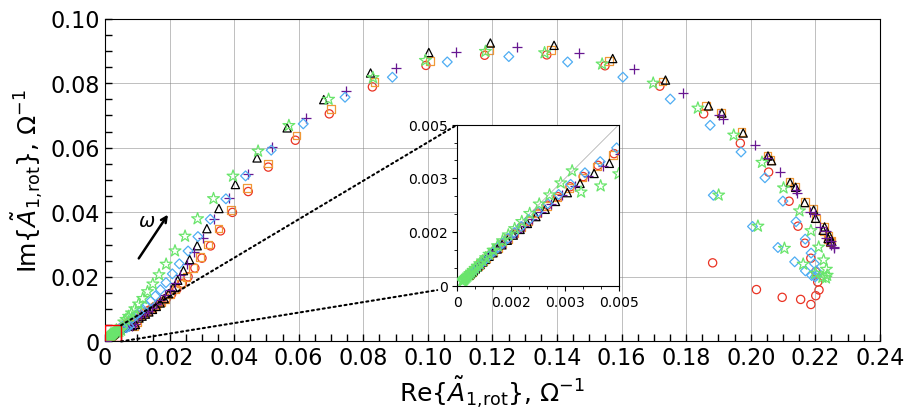

In [10]:
# Create Figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Variables
frequency = df["Freq"]
file_num = "1"
labels = [1, 5, 10, 20, 50, 100]
labels = [f"{round(x*np.sqrt(2),3)} mV" for x in labels]
names = ["1mV","5mV","10mV","20mV","50mV","100mV"]
markers = ["o", "s", "^", "+", "D", "*"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145), (79, 173, 243), (106, 229, 108)]
sizes = [35,30,35,45,25,80]
colors = [tuple(c/255 for c in color) for color in colors]
linewidth = .9

#Plot Each Potential Modulation
for count in range(0,len(sizes)):
    label_val = labels[count]
    shape = markers[count]
    color_val = colors[count]
    size = sizes[count]
    name = names[count]
    real_A = df[f"Re{{A1}} Rot, {name} (File {file_num})"]
    imag_A = df[f"Im{{A1}} Rot, {name} (File {file_num})"]

    # Plot Unfilled Markers on Scatter Plot
    if (shape == "+"):
        ax.scatter(real_A, imag_A, color=color_val, label=label_val,
                zorder=count, s=size, linewidth=linewidth, marker=shape)
    else:
        ax.scatter(real_A, imag_A, facecolors='none', label=label_val,
                s=size, linewidth=linewidth, marker=shape, edgecolor=color_val,
                zorder=count)

# 45-degree gray line spanning data range
min_val = min(df.iloc[:, 1::2].min().min(), df.iloc[:, 2::2].min().min())
max_val = max(df.iloc[:, 1::2].max().max(), df.iloc[:, 2::2].max().max())
line_min = min_val if min_val > 0 else 0
line_max = max_val

# Format Axes
ax.set_xlabel(r'Re{$\tilde{A}_{1,\!\mathrm{rot}}$}, $\Omega^{-1}$', fontsize=18)
ax.set_ylabel(r'Im{$\tilde{A}_{1,\!\mathrm{rot}}$}, $\Omega^{-1}$', fontsize=18)
ax.set_aspect('equal', adjustable='box')

# Format Grid/Tick Marks
ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax.set_xlim(0, 0.24)
ax.set_ylim(0, 0.1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.minorticks_on()
ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
ax.tick_params(which='major', direction='in', labelsize=16,length=5,width=1)

# Remove Decimals on 0 at Origin
def custom_formatter(x, pos):
    return '0' if abs(x) < 1e-9 else f'{x:.2f}'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

# Arrow annotation for increasing omega along 45-degree line
arrow_start = 0.01
arrow_end = 0.02
offset = 0.015  # small positive offset above the line
dx = arrow_end - arrow_start
slope = 1.5
y_start = arrow_start + offset
y_end = y_start + slope * dx
ax.annotate("",
            xy=(arrow_end, y_end),
            xytext=(arrow_start, y_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
ax.text(
    (arrow_start + arrow_end) / 2 - 0.002,  # x position (midpoint)
    (y_start + y_end) / 2 + 0.002,         # y position slightly above arrow
    r'$\omega$',
    ha='center',
    va='bottom',   # align text bottom to this y position
    fontsize=14
)
# Plotting Zoomed in Overlay Plot
    # Zoomed inset axes
axins = inset_axes(ax, width="50%", height="50%", 
                   bbox_to_anchor=(0.3, 0.15, 1, 1),
                   bbox_transform=ax.transAxes, loc='lower left')

    # Zoom region (near origin)
x1, x2 = 0, 0.005  # x-limits of zoom
y1, y2 = 0, 0.005  # y-limits of zoom
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_aspect('equal', adjustable='box')

    # Rectangle on main plot to indicate zoom
rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='red', facecolor='none', zorder=5)
ax.add_patch(rect)
x_offset = 0.0003  # Small offset for x so lines don’t hit y-axis labels

    # Main rectangle corners (in main axes data)
main_bottom_left = (x2, y1)
main_top_left = (x2, y2)

    # Inset rectangle corners (in inset axes data), slightly shifted left
inset_top_left = (x2, y2)
inset_top_right = (x2, y1)

    # Dotted lines to Indicate Zoom Plot
con1 = ConnectionPatch(
    xyA=main_top_left, xyB=(0, 1),  # xyB in axes fraction
    coordsA="data", coordsB="axes fraction",
    axesA=ax, axesB=axins,
    linestyle='dotted', color='black', lw=1.5, zorder=5
)
con2 = ConnectionPatch(
    xyA=main_bottom_left, xyB=(-0.125, -0.025),  # xyB in axes fraction
    coordsA="data", coordsB="axes fraction",
    axesA=ax, axesB=axins,
    linestyle='dotted', color='black', lw=1.5, zorder=5
)
ax.add_artist(con1)
ax.add_artist(con2)
    # Re-Plotting the same scatter inside the inset plot
for count in range(0,len(sizes)):
    label_val = labels[count]
    shape = markers[count]
    color_val = colors[count]
    size = sizes[count]
    name = names[count]
    real_A = df[f"Re{{A1}} Rot, {name} (File {file_num})"]
    imag_A = df[f"Im{{A1}} Rot, {name} (File {file_num})"]

    if shape == "+":
        axins.scatter(real_A, imag_A, color=color_val,
                    s=size, linewidth=linewidth, marker=shape, zorder=count)
    else:
        axins.scatter(real_A, imag_A, facecolors='none', edgecolor=color_val,
                    s=size, linewidth=linewidth, marker=shape, zorder=count)
        
    # Inset grid & ticks
axins.tick_params(which='major', labelsize=10)
axins.tick_params(which='minor', labelbottom=False, labelleft=False)

    # Formatting Tick Marks
major_ticks = np.linspace(0, 0.005, 4)
axins.set_xticks(major_ticks)
axins.set_yticks(major_ticks)
axins.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 3 minor ticks between majors
axins.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

    # Keep your custom formatting for small values
def custom_formatter(x, pos):
    return '0' if abs(x) < 1e-9 else f'{x:.3f}'
axins.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
axins.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

    #Plot 45-degree Line
axins.plot([x1, x2], [y1, y2], color='gray', linestyle='-', linewidth=0.5, alpha=0.7, zorder=1)

#Show/Save Figure
plt.savefig("S3_First_Harmonic_2nd_Order_Admittance_all_Freq.png", dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


### 4. First Harmonic Admittance (No Cdl Correction) Plot

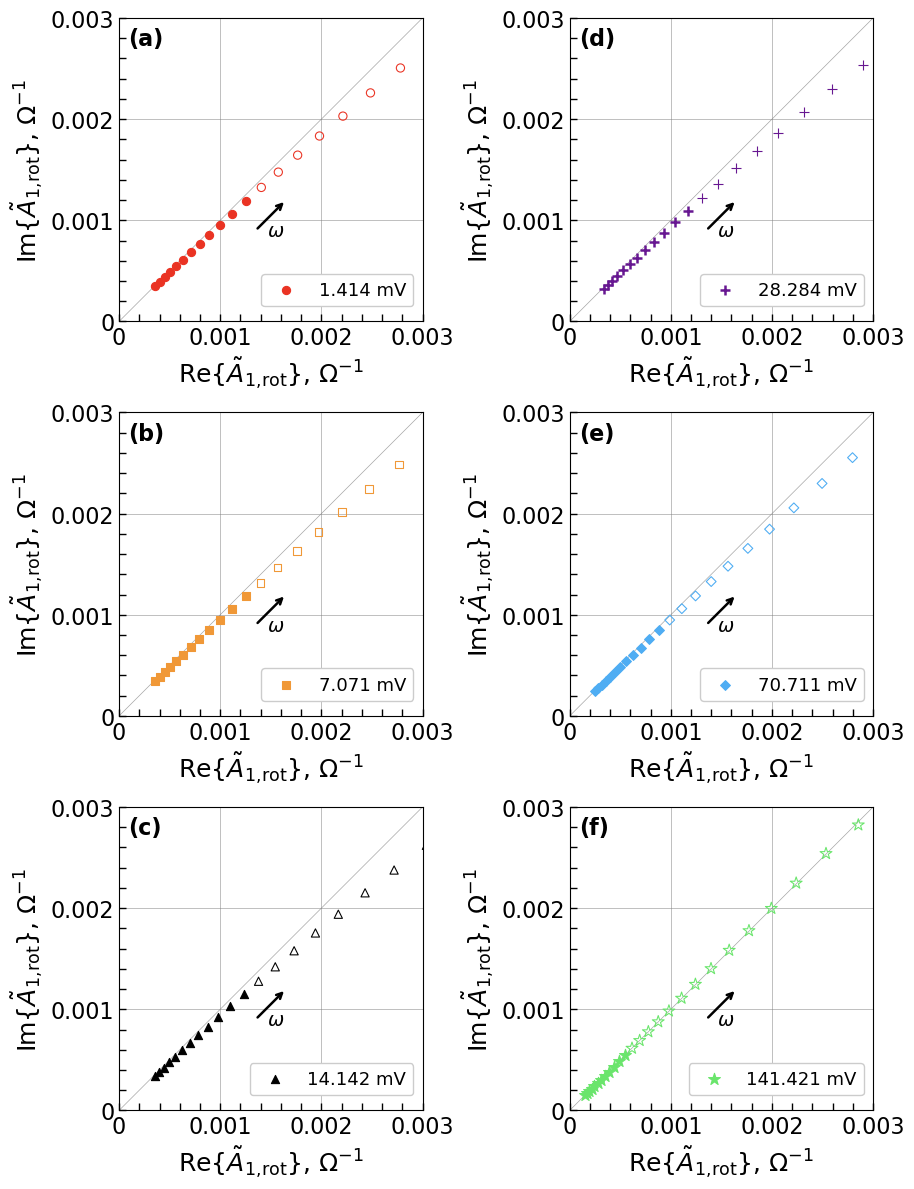

In [11]:
#Create Figure
fig, axes = plt.subplots(3, 2, figsize=(10, 12))  # 3 rows x 2 cols
axes = axes.T.flatten()

# Plot Variables
frequency = df["Freq"]
length = len(df.columns)
num_freq = len(frequency)
end = num_freq - 12
labels = [1, 5, 10, 20, 50, 100]
labels = [f"{round(x*np.sqrt(2),3)} mV" for x in labels]
markers = ["o", "s", "^", "+", "D", "*"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145), (79, 173, 243), (106, 229, 108)]
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
sizes = [35,30,35,45,25,80]
names = ["1mV","5mV","10mV","20mV","50mV","100mV"]

for count in range(0,len(sizes)):
    ax = axes[count]
    label_val = labels[count]
    shape = markers[count]
    color_val = tuple(x / 255 for x in colors[count])
    size = sizes[count]
    name = names[count]
    real_A = df[f"Re{{A1}} Rot, {name} (File {file_num})"]
    imag_A = df[f"Im{{A1}} Rot, {name} (File {file_num})"]

    #Plot Smallest 12 Frequencies Filled in and Other Frequencies Unfilled
    if (shape == "+"):
        ax.scatter(real_A.iloc[end:], imag_A.iloc[end:], color=color_val, label=label_val,
                   zorder=5, s=size, linewidth=1.8, marker=shape)
        ax.scatter(real_A.iloc[:end], imag_A.iloc[:end], color=color_val,
                   zorder=5, s=size, linewidth=0.8, marker=shape)
    else:
        ax.scatter(real_A.iloc[end:], imag_A.iloc[end:], color=color_val, label=label_val,
                   zorder=5, s=size, linewidth=0.78, marker=shape)
        ax.scatter(real_A.iloc[:end], imag_A.iloc[:end], edgecolor=color_val, facecolors='none',
                   zorder=5, s=size, linewidth=0.78, marker=shape)
    
    # 45-degree gray line
    ax.plot([0, 0.003], [0, 0.003], color='gray', linestyle='-', linewidth=0.5, alpha=0.7, zorder=1)
        
    # Format Axes
    ax.set_xlabel(r'Re{$\tilde{A}_{1,\!\mathrm{rot}}$}, $\Omega^{-1}$', fontsize=18)
    ax.set_ylabel(r'Im{$\tilde{A}_{1,\!\mathrm{rot}}$}, $\Omega^{-1}$', fontsize=18)
    ax.set_xlim(0, 0.003)
    ax.set_ylim(0, 0.003)
    ax.set_aspect('equal', adjustable='box')

    # Format Grid/Tick Marks
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.001))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.001))
    ax.minorticks_on()

    # Remove Decimals on 0 at Origin
    def custom_formatter(x, pos):
        return '0' if abs(x) < 1e-9 else f'{x:.3f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

    # Tick appearance
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
    ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
    ax.tick_params(which='major', direction='in', labelsize=16,length=5,width=1)
    ax.text(0.03, 0.97, subplot_labels[count], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
    ax.legend(fontsize=13, loc="lower right", bbox_to_anchor=(1, 0.02),framealpha=1)
    
    # Arrow annotation for increasing omega
    arrow_frac_start = 0.45
    arrow_frac_end   = 0.55
    offset_frac = -0.15  # downward offset
    
    add_fraction_diagonal_arrow(ax,
            start_frac = arrow_frac_start,
            end_frac = arrow_frac_end,
            offset_frac= offset_frac,
            label=r'$\omega$',
            fontsize=14,
            lw=1.8)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0.3)
plt.savefig(f"S4_First_Harmonic_2nd_Order_Admittance_Near_Origin.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


### 5. I1 Rot Vs I1 Processed Comparison Plot

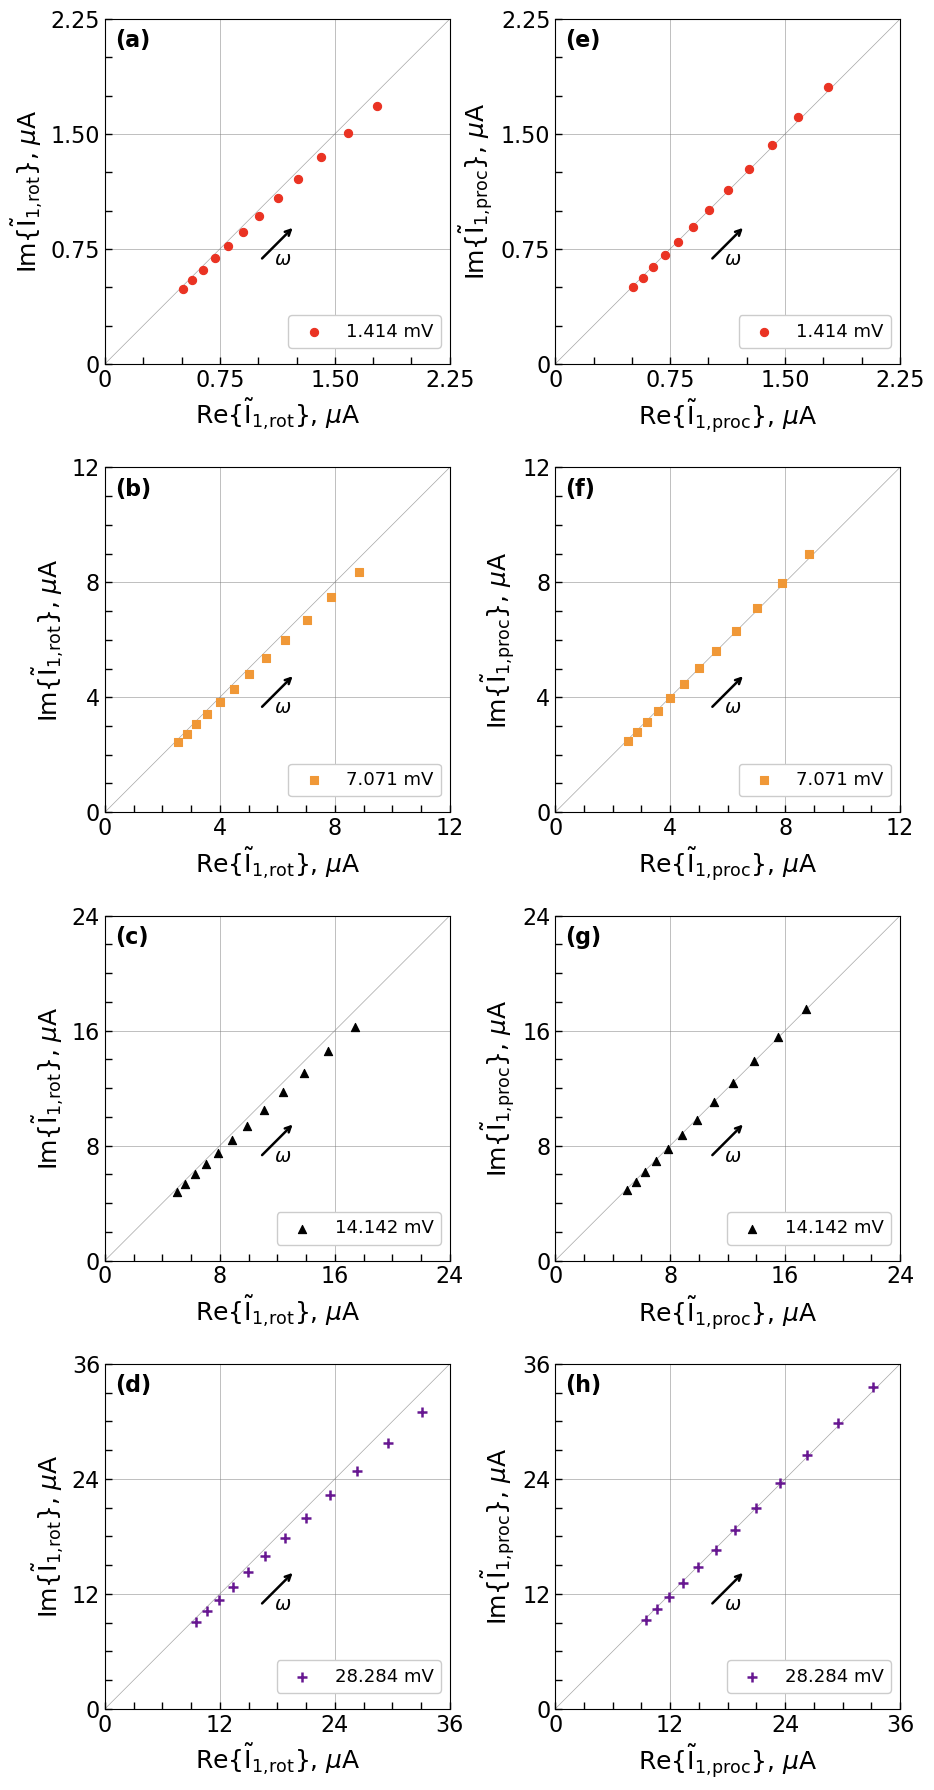

In [12]:
# --- Figure setup ---
fig, axes = plt.subplots(4, 2, figsize=(10, 18))  # 3 rows x 2 cols
axes = axes.T.flatten()

# --- Data setup ---
frequency = df3["Freq"]
length = len(df3.columns) - 4  # removing 50 mV, 100 mV, and two times
num_freq = len(frequency)
end = num_freq - 12

labels = [1, 5, 10, 20, 50, 100]
labels = [f"{round(x*np.sqrt(2),3)} mV" for x in labels]
markers = ["o", "s", "^", "+"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145)]
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']
sizes = [35, 30, 35, 45]

lim = [2.25E-6, 1.2E-5, 2.4E-5, 3.6E-5]
voltages = [1, 5, 10, 20, 50, 100]
voltages = [x * 1e-3 for x in voltages]
names = ["1mV", "5mV", "10mV", "20mV"]
major_ticks = [0.75E-6,0.4E-5,0.8E-5,1.2E-5,]
minor_ticks = [0.25E-6,0.1E-5,0.2E-5,0.3E-5]

count = 0

for k in range(2):  # k = 0 (original), k = 1 (Cdl corrected)
    for t_count in range(0, len(sizes)):
        ax = axes[count]
        label_val = labels[t_count]
        shape = markers[t_count]
        color_val = tuple(x / 255 for x in colors[t_count])
        size = sizes[t_count]
        name = names[t_count]
        major_tick = major_ticks[t_count]
        minor_tick = minor_ticks[t_count]
        if k == 0:
            real_I = df3[f"Re{{I1}} Rot, {name} (File {file_num})"].iloc[end:]
            imag_I = df3[f"Im{{I1}} Rot, {name} (File {file_num})"].iloc[end:]
        else:
            real_I = df3_corr[f"IHr1, {name} (File {file_num})"]
            imag_I = df3_corr[f"IHi1, {name} (File {file_num})"]

        # --- Scatter plots ---
        if shape == "+":
            ax.scatter(real_I, imag_I, color=color_val, label=label_val,
                       zorder=5, s=size, linewidth=1.8, marker=shape)
        else:
            ax.scatter(real_I, imag_I, color=color_val, label=label_val,
                       zorder=5, s=size, linewidth=0.78, marker=shape)

        # --- 45-degree gray line ---
        ax.plot([0, lim[t_count]], [0, lim[t_count]], color='gray', linestyle='-', linewidth=0.5, alpha=0.7, zorder=1)

        # --- Axis limits and square aspect ---
        xlim = lim[t_count]
        ylim = lim[t_count]
        ax.set_xlim(0, xlim)
        ax.set_ylim(0, ylim)
        ax.set_aspect('equal', adjustable='box')
        if count < 4:
            ax.set_xlabel(r'Re{$\tilde{\mathrm{I}}_{\mathrm{1,\!\mathrm{rot}}}$}, $\mu$A', fontsize=18)
            ax.set_ylabel(r'Im{$\tilde{\mathrm{I}}_{\mathrm{1, \!\mathrm{rot}}}$}, $\mu$A', fontsize=18)
        else:
            ax.set_xlabel(r'Re{$\tilde{\mathrm{I}}_{\mathrm{1,\!\mathrm{proc}}}$}, $\mu$A', fontsize=18)
            ax.set_ylabel(r'Im{$\tilde{\mathrm{I}}_{\mathrm{1,\!\mathrm{proc}}}$}, $\mu$A', fontsize=18)

        # --- Dynamic ticks ---
        ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
        num_major_ticks = 3
        major_tick_x = xlim / num_major_ticks
        major_tick_y = ylim / num_major_ticks
        ax.xaxis.set_major_locator(ticker.MultipleLocator(major_tick))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(major_tick))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_tick))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor_tick))

        # --- Custom formatter to scale by 10^-6 ---
        def make_micro_formatter(count):
            def micro_formatter(x, pos):
                if count in (0, 4):  # use tuple membership, easier to extend
                    return '0' if abs(x) < 1e-9 else f'{x*1e6:.2f}'
                else:
                    return '0' if abs(x) < 1e-9 else f'{x*1e6:.0f}'
            return micro_formatter
                
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(make_micro_formatter(count)))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(make_micro_formatter(count)))

        # --- Tick appearance ---
        ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
        ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
        ax.tick_params(which='major', direction='in', labelsize=16, length=5, width=1)

        # --- Subplot label and legend ---
        ax.text(0.03, 0.97, subplot_labels[count], transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='top', ha='left')
        ax.legend(fontsize=13, loc="lower right", bbox_to_anchor=(1, 0.02), framealpha=1)

        # --- Arrow annotation for increasing omega (dynamic, lower) ---
        arrow_frac_start = 0.45
        arrow_frac_end   = 0.55
        x_range = xlim
        y_range = ylim
        offset_frac = -0.15  # downward offset
        
        add_fraction_diagonal_arrow(ax,
                start_frac = arrow_frac_start,
                end_frac = arrow_frac_end,
                offset_frac= offset_frac,
                label=r'$\omega$',
                fontsize=14,
                lw=1.8)

        count += 1

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0.3)
plt.savefig(f"S1_First_Harmonic_Rot_Proc_Current_Comparison.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


# 6. 2nd Harmonic Plot

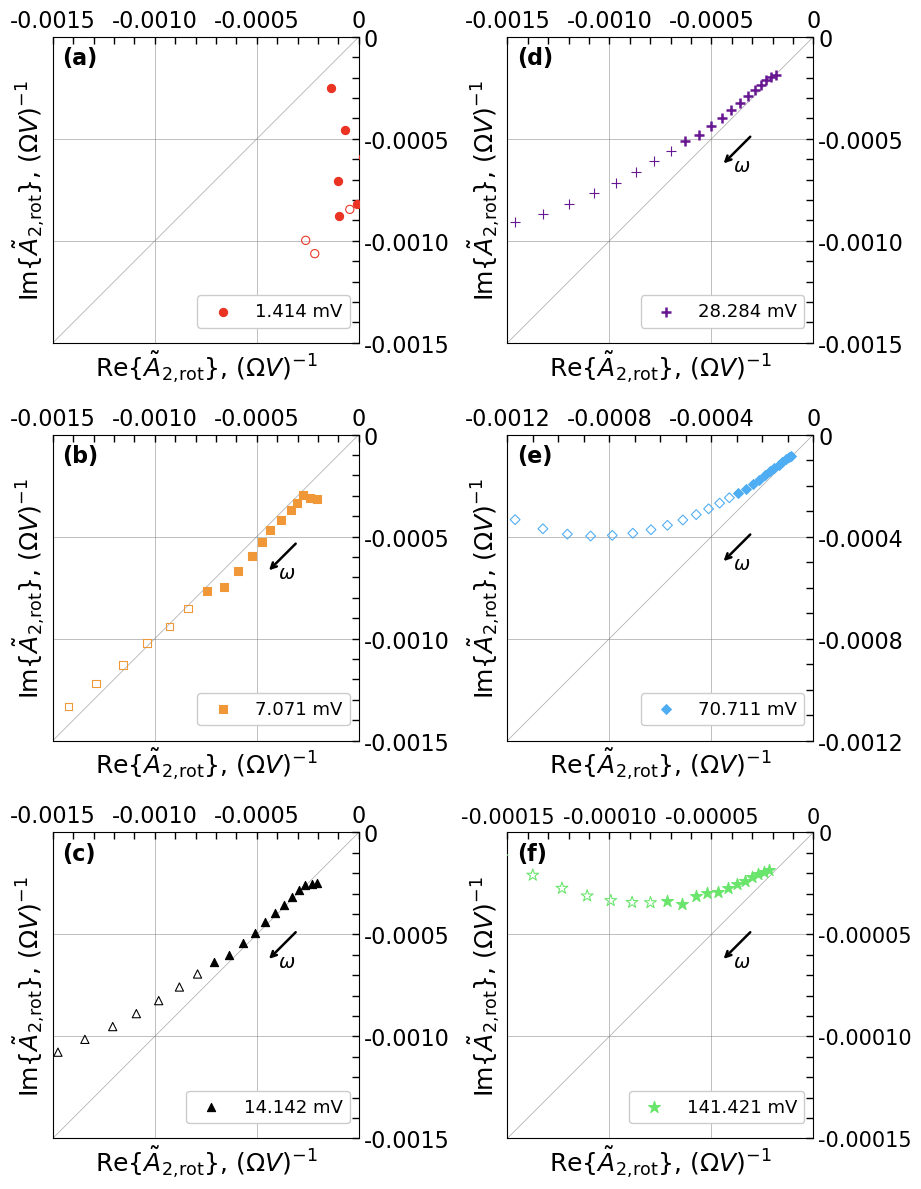

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))  # 3 rows x 2 cols
axes = axes.T.flatten()

# Index Lengths
frequency = df2["Freq"]
length = len(df2.columns)
num_freq = len(frequency)
end = num_freq - 12

# Labels, Markers, Colors
labels = [1, 5, 10, 20, 50, 100]
labels = [f"{round(x*np.sqrt(2),3)} mV" for x in labels]
markers = ["o", "s", "^", "+", "D", "*"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145), (79, 173, 243), (106, 229, 108)]
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
sizes = [35,30,35,45,25,80]
max_x_limits = [-0.0015,-0.0015,-0.0015,-0.0015,-0.0012,-0.00015]
max_y_limits = [-0.0015,-0.0015,-0.0015,-0.0015,-0.0012,-0.00015]
major_ticks = [0.0005,0.0005,0.0005,0.0005,0.0004,0.00005]
minor_ticks = [0.0001,0.0001,0.0001,0.0001,0.0001,0.00001]
decimal_nums = [4,4,4,4,4,5]
arrow_starts = [0.8,0.8,0.8,0.8,0.8,0.8]
arrow_ends = [0.7,0.7,0.7,0.7,0.7,0.7]
offsets = [-0.12,-0.15,-0.12,-0.12,-0.12,-0.12]
names = ["1mV", "5mV", "10mV", "20mV", "50mV", "100mV"]

for count in range(0,len(names)):
    ax = axes[count]
    
    label_val = labels[count]
    shape = markers[count]
    color_val = tuple(x / 255 for x in colors[count])
    size = sizes[count]
    max_x_limit = max_x_limits[count]
    max_y_limit = max_y_limits[count]
    major_tick = major_ticks[count]
    minor_tick = minor_ticks[count]
    decimal_num = decimal_nums[count]
    name = names[count]
    real_A = df2[f"Re{{A2}} Rot, {name} (File {file_num})"]
    imag_A = df2[f"Im{{A2}} Rot, {name} (File {file_num})"]

    if (shape == "+"):
        ax.scatter(real_A.iloc[end:], imag_A.iloc[end:], color=color_val, label=label_val,
                   zorder=5, s=size, linewidth=1.8, marker=shape)
        ax.scatter(real_A.iloc[:end], imag_A.iloc[:end], color=color_val,
                   zorder=5, s=size, linewidth=0.8, marker=shape)
    else:
        ax.scatter(real_A.iloc[end:], imag_A.iloc[end:], color=color_val, label=label_val,
                   zorder=5, s=size, linewidth=0.78, marker=shape)
        ax.scatter(real_A.iloc[:end], imag_A.iloc[:end], edgecolor=color_val, facecolors='none',
                   zorder=5, s=size, linewidth=0.78, marker=shape)
    # 45-degree gray line
    ax.plot([0, -0.004], [0, -0.004], color='gray', linestyle='-', linewidth=0.5, alpha=0.7, zorder=1)
        
    # Labels and limits
    ax.set_xlabel(r'Re{$\tilde{A}_{2,\!\mathrm{rot}}$}, ${(\Omega V)}^{-1}$', fontsize=18)
    ax.set_ylabel(r'Im{$\tilde{A}_{2,\!\mathrm{rot}}$}, ${(\Omega V)}^{-1}$', fontsize=18)
    ax.set_xlim(max_x_limit, 0)
    ax.set_ylim(max_y_limit, 0)
    ax.set_aspect('equal', adjustable='box')

    # Grid and ticks
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_tick))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_tick))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_tick))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor_tick))
    ax.yaxis.tick_right()
    ax.xaxis.tick_top()

    # Custom tick formatting
    def get_custom_formatter(decimal_num):
        def formatter(x, pos):
            return '0' if abs(x) < 1e-9 else f'{x:.{decimal_num}f}'
        return formatter
    
    formatter = ticker.FuncFormatter(get_custom_formatter(decimal_num))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    # Tick appearance
    if count == 5:
        t_size = 15 #extra decmials make number hard to read with larger texy
    else: 
        t_size = 16
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
    ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
    ax.tick_params(which='major', direction='in', labelsize=t_size,length=5,width=1)
    ax.text(0.03, 0.97, subplot_labels[count], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
    ax.legend(fontsize=13, loc="lower right", bbox_to_anchor=(1, 0.02),framealpha=1)
    
    if count == 0:
        continue
    else:
        # --- Arrow annotation for increasing omega (dynamic, lower) ---
        add_fraction_diagonal_arrow(ax,
                       start_frac = arrow_starts[count],
                       end_frac = arrow_ends[count],
                       offset_frac= offsets[count],
                       label=r'$\omega$',
                       fontsize=14,
                       lw=1.8)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0.3)
plt.savefig(f"S5_Second_Harmonic_2nd_Order_Admittance_Near_Origin.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()
